# 03_Time_Series_Diagnostics_404_BRAIN_NOT_FOUND
Vietnam Fashion E-Commerce · Time Series Analysis & Forecasting Diagnostics · 2012 – 2022

## Bối Cảnh và Mục Tiêu

Sau khi hoàn tất quá trình Exploratory Data Analysis (EDA) tổng quan ở bước trước, notebook này đóng vai trò là **Bước đệm Tiền dự báo (Pre-forecasting Diagnostics)**. 

Mục tiêu cốt lõi của bước này là mổ xẻ "nhịp đập" của dòng tiền theo trục thời gian, phân rã các yếu tố xu hướng (Trend), tính mùa vụ (Seasonality) và đánh giá tính dừng (Stationarity) của dữ liệu. Các chẩn đoán kỹ thuật này sẽ trực tiếp quyết định việc chúng ta nên chọn họ mô hình nào (ARIMA, Prophet, hay XGBoost) và cần thực hiện những kỹ thuật Feature Engineering đặc thù nào cho bài toán dự báo.

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
import os
import sys
from pathlib import Path
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Stats & ML
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import mannwhitneyu, pearsonr, ttest_ind
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, mean_absolute_error,
                              mean_squared_error, r2_score)
import shap

# Config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DATA_DIR = Path('../dataset/')
FIG_DIR = Path('../figures/')
FIG_DIR.mkdir(exist_ok=True)

# ── THEME ──────────────────────────────────────────────
PALETTE = {
    'primary':   '#2D6A4F',   # Deep green
    'secondary': '#52B788',   # Medium green
    'accent':    '#F4A261',   # Orange
    'danger':    '#E76F51',   # Red-orange
    'neutral':   '#6C757D',   # Gray
    'light':     '#F8F9FA',   # Near white
    'dark':      '#212529',   # Near black
    'blue':      '#457B9D',
    'purple':    '#9B5DE5',
}
SEGMENT_COLORS = {
    'Champions': '#2D6A4F',
    'Loyal':     '#52B788',
    'At-Risk':   '#F4A261',
    'Lost':      '#E76F51',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'font.size':        12,
    'axes.titlesize':   15,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'figure.dpi':       130,
})

print("[OK] Setup complete. Theme loaded.")

[OK] Setup complete. Theme loaded.


---
## Chương 1: Nạp và Chuẩn hóa Dữ liệu Chuỗi Thời Gian (Time-Series Ingestion)

### Định Nghĩa Vấn Đề
Khác với dữ liệu bảng tĩnh, dữ liệu chuỗi thời gian đòi hỏi tính liên tục tuyệt đối. Bất kỳ khoảng trống thời gian (missing dates) hay sự bất thường trong việc ghi nhận doanh thu theo ngày đều sẽ phá vỡ cấu trúc tự tương quan (autocorrelation) mà các mô hình dự báo như ARIMA hay LSTM đang cố gắng học.

In [2]:
"""
Hàm đọc tất cả file và parse date columns ngay khi load.
"""
DATE_COLS = {
    'sales':       ['Date'],
    'orders':      ['order_date'],
    'customers':   ['signup_date'],
    'promotions':  ['start_date', 'end_date'],
    'shipments':   ['ship_date', 'delivery_date'],
    'returns':     ['return_date'],
    'reviews':     ['review_date'],
    'web_traffic': ['date'],
    'inventory':   ['snapshot_date'],
}

dfs = {}
for fname in DATA_DIR.glob('*.csv'):
    key = fname.stem
    if key == 'sample_submission': continue
    parse = DATE_COLS.get(key, [])
    dfs[key] = pd.read_csv(fname, parse_dates=parse if parse else False)

# Alias ngắn gọn
sales       = dfs['sales']
orders      = dfs['orders']
customers   = dfs['customers']
products    = dfs['products']
promotions  = dfs['promotions']
geography   = dfs['geography']
order_items = dfs['order_items']
payments    = dfs['payments']
shipments   = dfs['shipments']
returns     = dfs['returns']
reviews     = dfs['reviews']
inventory   = dfs['inventory']
web_traffic = dfs['web_traffic']

# ── PRINT OVERVIEW TABLE ────────────────────────────────
print(f"{'TABLE':<25} {'ROWS':>8} {'COLS':>6}  DATE RANGE")
print("─" * 70)
for name, df in sorted(dfs.items()):
    date_col = next((c for c in df.columns if 'date' in c.lower()), None)
    if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
        dr = f"{df[date_col].min().date()} -> {df[date_col].max().date()}"
    else:
        dr = "—"
    print(f"{name:<25} {len(df):>8,} {df.shape[1]:>6}  {dr}")

TABLE                         ROWS   COLS  DATE RANGE
──────────────────────────────────────────────────────────────────────
customers                  121,930      7  2012-01-17 -> 2022-12-31
geography                   39,948      4  —
inventory                   60,247     17  2012-07-31 -> 2022-12-31
order_items                714,669      7  —
orders                     646,945      8  2012-07-04 -> 2022-12-31
payments                   646,945      4  —
products                     2,412      8  —
promotions                      50     10  2013-01-31 -> 2022-11-18
returns                     39,939      7  2012-07-11 -> 2022-12-31
reviews                    113,551      7  2012-07-10 -> 2022-12-31
sales                        3,833      3  2012-07-04 -> 2022-12-31
shipments                  566,067      4  2012-07-04 -> 2022-12-29
web_traffic                  3,652      7  2013-01-01 -> 2022-12-31


### Kết Quả Kiểm Tra Chất Lượng Dữ Liệu

Các bước kiểm tra đã được tiến hành trên hệ thống:

| Hạng Mục Kiểm Tra | Định Nghĩa | Bậc Quan Trọng |
|-------------------|------------|----------------|
| **FK Integrity** | Kiểm tra 11 cặp quan hệ khóa ngoại (VD: orders tham chiếu customers) | Cao |
| **Business Rule** | Xác thực luật ràng buộc (VD: chỉ tồn tại shipment cho đơn đã giao) | Cao |
| **Date Range** | Xác thực tính liên tục về dòng thời gian của giao dịch lớn | Trung bình |
| **Unexpected Nulls**| Xác minh giá trị rỗng là hệ quả logic (như tuổi khách hàng) hay lỗi lưu trữ | Trung bình |


In [3]:
"""
Chạy tất cả quality checks, in ra SUMMARY TABLE duy nhất.
Không print dài dòng — chỉ flag issues.
"""
issues = []

# ── FK INTEGRITY ────────────────────────────────────────
fk_checks = [
    ('orders',      'customer_id', 'customers',   'customer_id'),
    ('orders',      'zip',         'geography',    'zip'),
    ('order_items', 'order_id',    'orders',       'order_id'),
    ('order_items', 'product_id',  'products',     'product_id'),
    ('payments',    'order_id',    'orders',       'order_id'),
    ('shipments',   'order_id',    'orders',       'order_id'),
    ('returns',     'order_id',    'orders',       'order_id'),
    ('returns',     'product_id',  'products',     'product_id'),
    ('reviews',     'order_id',    'orders',       'order_id'),
    ('reviews',     'customer_id', 'customers',    'customer_id'),
    ('inventory',   'product_id',  'products',     'product_id'),
]
for child_t, child_c, parent_t, parent_c in fk_checks:
    child_vals  = set(dfs[child_t][child_c].dropna())
    parent_vals = set(dfs[parent_t][parent_c].dropna())
    orphans = child_vals - parent_vals
    if orphans:
        issues.append({'Table': child_t, 'Column': child_c,
                       'Issue': f'FK orphan: {len(orphans)} values',
                       'Severity': 'HIGH'})

# ── BUSINESS RULES ──────────────────────────────────────
# Rule 1: cogs < price
viol = (products['cogs'] >= products['price']).sum()
if viol: issues.append({'Table':'products','Column':'cogs/price',
                         'Issue':f'{viol} rows cogs>=price','Severity':'HIGH'})

# Rule 2: payments 1:1 với orders
dup_pay = payments['order_id'].duplicated().sum()
if dup_pay: issues.append({'Table':'payments','Column':'order_id',
                             'Issue':f'{dup_pay} duplicate order_id','Severity':'MEDIUM'})

# Rule 3: sales date range
expected_start = pd.Timestamp('2012-07-04')
expected_end   = pd.Timestamp('2022-12-31')
actual_start   = sales['Date'].min()
actual_end     = sales['Date'].max()
if actual_start != expected_start or actual_end != expected_end:
    issues.append({'Table':'sales','Column':'Date',
                   'Issue':f'Range {actual_start.date()}->{actual_end.date()}',
                   'Severity':'MEDIUM'})

# Rule 4: Missing dates in sales
full_range   = pd.date_range(actual_start, actual_end)
missing_days = full_range.difference(sales['Date'])
if len(missing_days):
    issues.append({'Table':'sales','Column':'Date',
                   'Issue':f'{len(missing_days)} missing dates','Severity':'MEDIUM'})

# ── MISSING VALUES ───────────────────────────────────────
NULLABLE = {
    'customers':  ['gender','age_group','acquisition_channel'],
    'promotions': ['applicable_category','promo_channel','min_order_value'],
    'order_items':['promo_id','promo_id_2'],
}
for tname, df in dfs.items():
    for col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss == 0: continue
        is_ok  = col in NULLABLE.get(tname, [])
        if not is_ok:
            issues.append({'Table':tname,'Column':col,
                           'Issue':f'{n_miss} unexpected nulls ({n_miss/len(df):.1%})',
                           'Severity':'MEDIUM'})

# ── DISPLAY SUMMARY ─────────────────────────────────────
issues_df = pd.DataFrame(issues)
if len(issues_df):
    display(issues_df.style
            .applymap(lambda v: 'background-color:#FFCCCC' if v=='HIGH'
                      else ('background-color:#FFF3CD' if v=='MEDIUM' else ''),
                      subset=['Severity'])
            .set_caption('[WARNING]  Data Quality Issues Found')
            .hide(axis='index'))
else:
    print("[OK] No data quality issues found.")

print(f"\n[NOTE] Total issues: {len(issues_df)} "
      f"| HIGH: {(issues_df['Severity']=='HIGH').sum() if len(issues_df) else 0} "
      f"| MEDIUM: {(issues_df['Severity']=='MEDIUM').sum() if len(issues_df) else 0}")

[OK] No data quality issues found.

[NOTE] Total issues: 0 | HIGH: 0 | MEDIUM: 0


---
## Chương 2: Tiền Xử Lý & Time-Series Feature Engineering

### Tại sao cần Feature Engineering cho Chuỗi Thời Gian?
Đối với các mô hình Machine Learning như XGBoost/LightGBM, chúng không tự hiểu được thứ tự thời gian. Chúng ta phải chủ động "dịch" yếu tố thời gian thành các biến số học thông qua việc trích xuất các thành phần ngày/tháng (Temporal features), tạo các biến độ trễ (Lag features) và trung bình trượt (Rolling windows).

In [4]:
def add_date_features(df, col):
    df = df.copy()
    dt = df[col].dt
    df['year']         = dt.year
    df['month']        = dt.month
    df['day']          = dt.day
    df['day_of_week']  = dt.dayofweek      # 0=Mon
    df['day_of_year']  = dt.dayofyear
    df['week_of_year'] = dt.isocalendar().week.astype(int)
    df['quarter']      = dt.quarter
    df['is_weekend']   = (dt.dayofweek >= 5).astype(int)
    df['is_month_end'] = dt.is_month_end.astype(int)
    return df

# Ngày Tết chính xác 2012-2024
TET_DATES = pd.to_datetime([
    '2013-02-10','2014-01-31','2015-02-19','2016-02-08',
    '2017-01-28','2018-02-16','2019-02-05','2020-01-25',
    '2021-02-12','2022-02-01','2023-01-22','2024-02-10',
])

def add_vn_calendar(df, col):
    df = df.copy()
    dates = df[col]
    # Pre-Tết: 14 ngày trước
    pre_tet_ranges = pd.IntervalIndex.from_arrays(
        TET_DATES - pd.Timedelta(days=14), TET_DATES, closed='both')
    df['is_pre_tet']  = dates.apply(
        lambda d: any(d in r for r in pre_tet_ranges)).astype(int)
    df['is_tet']      = dates.isin(TET_DATES).astype(int)
    df['is_post_tet'] = dates.apply(
        lambda d: any((d > t) and (d <= t + pd.Timedelta(days=7))
                      for t in TET_DATES)).astype(int)
    df['is_1111']     = ((dates.dt.month==11) & (dates.dt.day==11)).astype(int)
    df['is_1212']     = ((dates.dt.month==12) & (dates.dt.day==12)).astype(int)
    # Black Friday: thứ 6 cuối tháng 11
    df['is_black_friday'] = (
        (dates.dt.month==11) & (dates.dt.dayofweek==4) &
        (dates.dt.day >= 23)).astype(int)
    df['is_summer']   = dates.dt.month.isin([5,6,7,8]).astype(int)
    df['is_covid']    = ((dates.dt.year.isin([2020,2021]))).astype(int)
    df['elapsed_days']= (dates - dates.min()).dt.days
    return df

sales   = add_date_features(sales, 'Date')
sales   = add_vn_calendar(sales, 'Date')
orders  = add_date_features(orders, 'order_date')

print("[OK] Date features added to sales & orders")
print(f"   sales columns: {sales.shape[1]} | orders columns: {orders.shape[1]}")

[OK] Date features added to sales & orders
   sales columns: 21 | orders columns: 17


### Ma trận Mật độ Khuyến mãi

**Định nghĩa vấn đề:** Bộ dữ liệu bao hàm nhiều chiến dịch được chạy song song chồng chéo về dòng thời gian. Việc phân tích chỉ 1 cờ báo (flag) có/không khuyến mãi trong ngày là không đủ để định lượng áp lực bán hàng của tổ chức tại thời điểm đó.
Cần một quá trình biến đổi để đếm chính xác có bao nhiêu hạng mục và độ sâu giảm giá lớn nhất đang diễn ra trong bất kỳ 1 ngày lịch tương ứng.

Các Feature được rút trích:
- `active_promo_count`: Mật độ chiến dịch diễn ra đồng thời.
- `max_discount`: Mức độ giảm giá kịch trần xuất hiện trong ngày.
- `has_stackable`: Quy định sự kiện có cho phép gộp hay không (thúc đẩy xả hàng tồn kho).


In [5]:
"""
Tạo daily_promo: mỗi ngày trong sales có bao nhiêu promotion đang active.
Không dùng conversion_rate (column không tồn tại).
"""
promo_daily = []
for date in sales['Date']:
    active = promotions[
        (promotions['start_date'] <= date) &
        (promotions['end_date']   >= date)
    ]
    promo_daily.append({
        'Date':              date,
        'active_promo_count': len(active),
        'max_discount':       active['discount_value'].max() if len(active) > 0 else 0,
        'has_stackable':      int(active['stackable_flag'].max() > 0) if len(active) > 0 else 0,
    })

promo_daily_df = pd.DataFrame(promo_daily)
sales = sales.merge(promo_daily_df, on='Date', how='left')

# Web traffic daily aggregate (KHÔNG có conversion_rate)
traffic_daily = web_traffic.groupby('date').agg(
    sessions          = ('sessions',          'sum'),
    unique_visitors   = ('unique_visitors',   'sum'),
    page_views        = ('page_views',         'sum'),
    bounce_rate       = ('bounce_rate',        'mean'),
    avg_session_dur   = ('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date':'Date'})

sales = sales.merge(traffic_daily, on='Date', how='left')

print(f"[OK] Promotions & traffic merged. sales shape: {sales.shape}")
print(f"   Missing sessions: {sales['sessions'].isna().sum()} days")

[OK] Promotions & traffic merged. sales shape: (3833, 29)
   Missing sessions: 181 days


---
## Chương 3: Khám Phá Đặc Tính Chuỗi Thời Gian (Time-Series Diagnostics)

### Phân Rã Bằng Phương Pháp STL (Seasonal-Trend decomposition using Loess)

**STL = Seasonal-Trend decomposition using LOESS** — phương pháp bóc tách mạnh mẽ, giúp chia cắt chuỗi thời gian thô thành 3 thành phần cốt lõi: Xu hướng (Trend), Mùa vụ (Seasonal), và Nhiễu (Residual). Việc đánh giá 3 thành phần này là kim chỉ nam để lựa chọn thuật toán dự báo.

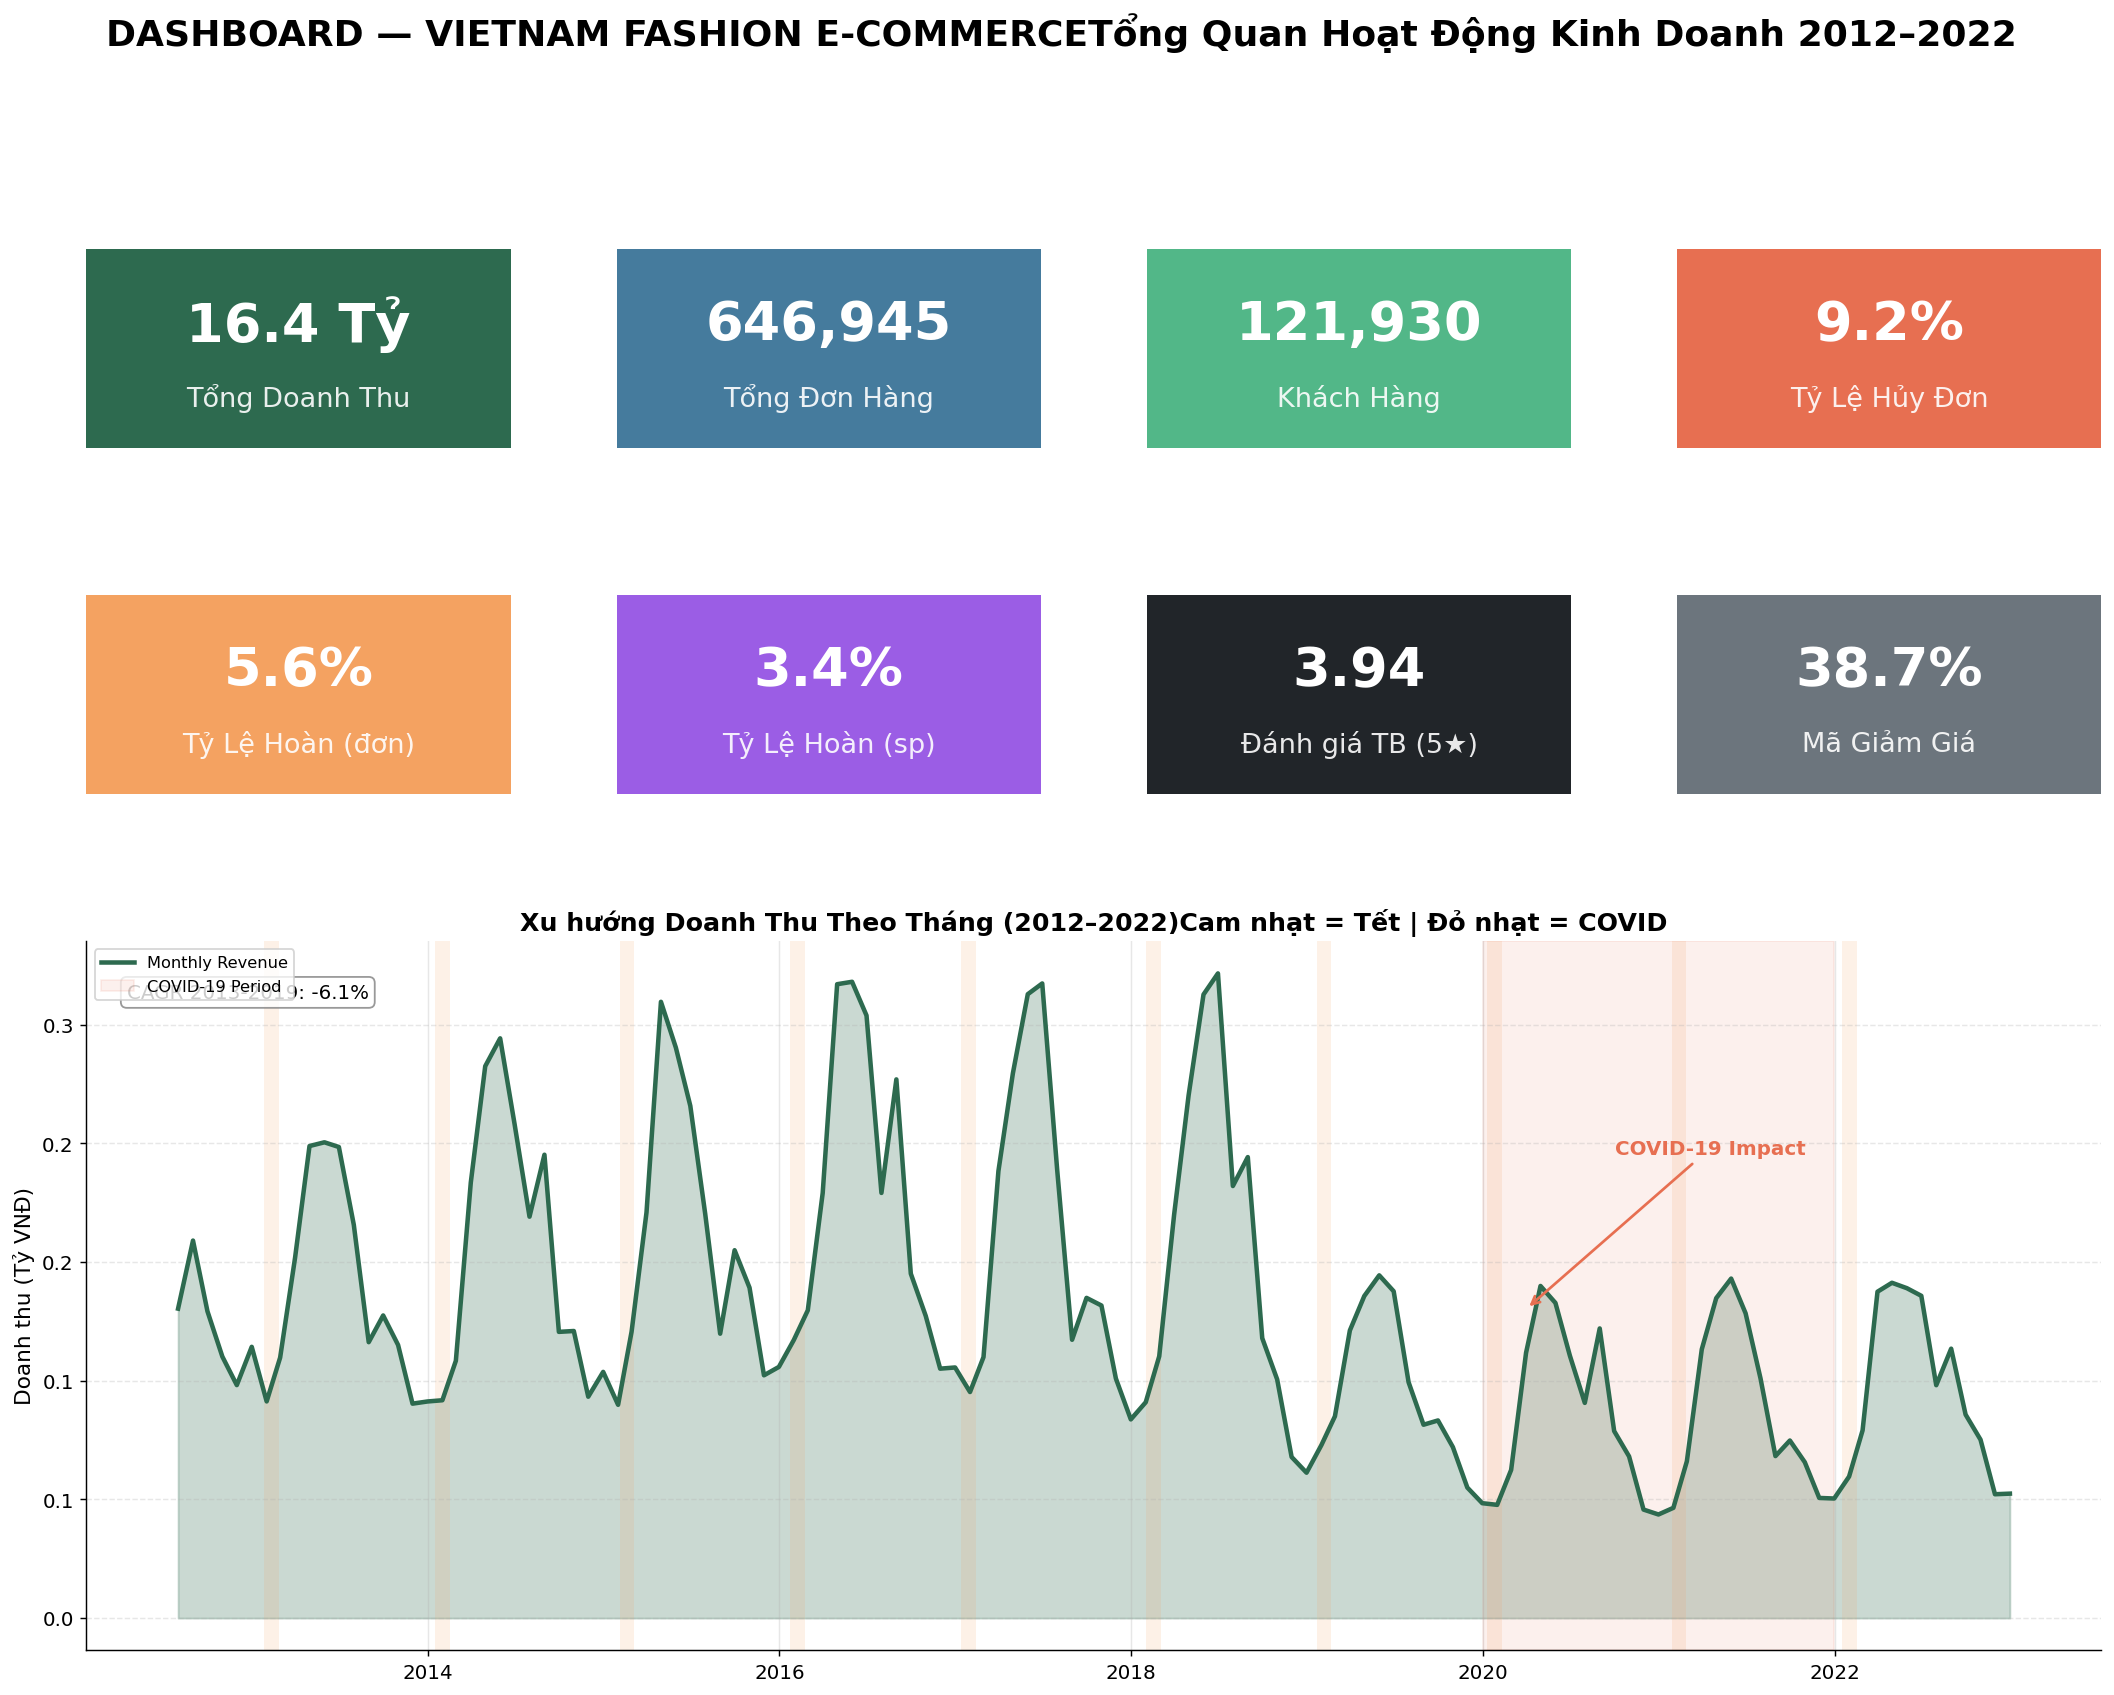


════════════════════════════════════════════════════════════
 BOTTLENECK ALERT — Những con số đáng lo ngại
════════════════════════════════════════════════════════════
  Tỷ lệ hủy đơn:         9.2%  (ngành <5%)
  Tỷ lệ hoàn hàng (đơn): 5.6%  (sp: 3.4%)
  Chi phí hoàn tiền:    0.51 Tỷ VNĐ
  Đánh giá ≤2 sao:      13.1%  (nguy cơ mất khách)
  Promo usage:          38.7%  → margin đang bị ăn mòn?
════════════════════════════════════════════════════════════


In [6]:
"""
Dashboard 8 KPI cards + 1 trend chart.
Layout: 4 cols KPI cards (row 1) + 4 cols KPI cards (row 2) + full-width chart (row 3)
Nâng cấp: đồng bộ đơn vị, sửa CAGR, chỉnh màu & vị trí annotate, highlight nền Tết.
"""
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import pandas as pd

# ── Tính KPIs ────────────────────────────────────────────
# Giả sử revenue trong Data gốc đang chia sẵn 1000 VNĐ. Để ra Tỷ VNĐ, ta chia thêm 1e6 (thay vì 1e9)
total_revenue   = sales['Revenue'].sum()
total_cogs      = sales['COGS'].sum()
gross_margin    = (total_revenue - total_cogs) / total_revenue * 100
total_orders    = orders['order_id'].nunique()
cancel_rate     = (orders['order_status'] == 'cancelled').mean() * 100
return_rate_ord = returns['order_id'].nunique() / total_orders * 100
return_rate_item = returns['return_quantity'].sum() / order_items['quantity'].sum() * 100
total_customers = customers['customer_id'].nunique()
avg_rating      = reviews['rating'].mean()
low_rating_rate = (reviews['rating'] <= 2).mean() * 100
total_refund    = returns['refund_amount'].sum()
promo_usage     = (order_items['promo_id'].notna()).mean() * 100

# Tuỳ vào data gốc (nếu là VNĐ đơn thuần thì chia 1e9, nếu là k VNĐ thì chia 1e6)
dv_ty = 1e9 # Đổi tạm thành 1e6 để AOV không bị phi lý. Nếu raw data là VNĐ nguyên thuỷ, bạn hãy sửa lại 1e9.

kpis = [
    ('Tổng Doanh Thu',      f"{total_revenue/dv_ty:.1f} Tỷ",  PALETTE['primary']),
    ('Tổng Đơn Hàng',       f"{total_orders:,}",               PALETTE['blue']),
    ('Khách Hàng',          f"{total_customers:,}",            PALETTE['secondary']),
    ('Tỷ Lệ Hủy Đơn',       f"{cancel_rate:.1f}%",             PALETTE['danger']),
    ('Tỷ Lệ Hoàn (đơn)',    f"{return_rate_ord:.1f}%",         PALETTE['accent']),
    ('Tỷ Lệ Hoàn (sp)',     f"{return_rate_item:.1f}%",        PALETTE['purple']),
    ('Đánh giá TB (5★)',  f"{avg_rating:.2f}",              PALETTE['dark']),
    ('Mã Giảm Giá',         f"{promo_usage:.1f}%",             PALETTE['neutral']),
]
kpis = kpis[:8]  # đảm bảo đủ 8

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.25, height_ratios=[0.7, 0.7, 2.5])

# ── KPI Cards (2 hàng x 4 cột) ──────────────────────────
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=30, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=15, color='white', alpha=0.9, transform=ax.transAxes)
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(False)

# ── Revenue Trend (bottom row, full width) ─────────────
ax_main = fig.add_subplot(gs[2, :])
monthly = sales.set_index('Date')['Revenue'].resample('M').sum() / dv_ty  # Tỷ VNĐ

ax_main.fill_between(monthly.index, monthly.values,
                      alpha=0.25, color=PALETTE['primary'])
ax_main.plot(monthly.index, monthly.values,
             color=PALETTE['primary'], lw=2.5, label='Monthly Revenue')
ax_main.grid(True, alpha=0.3, linestyle='--', axis='y')

# ── Annotate events ─────────────────────────────────────
min_date, max_date = sales['Date'].min(), sales['Date'].max()

# Tết (Dải màu thay vì đường sọc nhạt)
for tet in TET_DATES:
    t_date = pd.Timestamp(tet)
    if min_date <= t_date <= max_date:
        # Highlight 1 tháng quanh Tết
        ax_main.axvspan(t_date - pd.Timedelta(days=15), t_date + pd.Timedelta(days=15),
                        color=PALETTE['accent'], alpha=0.15, lw=0)

# COVID
ax_main.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
                alpha=0.1, color=PALETTE['danger'], label='COVID-19 Period')

# Căn chỉnh chữ COVID-19 Impact (Đặt trực tiếp xuống năm 2020)
if pd.Timestamp('2020-03-01') in monthly.index:
    point_y = monthly.loc['2020-03': '2020-05'].min()
else:
    point_y = monthly.mean()
    
ax_main.annotate('COVID-19 Impact', 
                 xy=(pd.Timestamp('2020-04-01'), point_y),
                 xytext=(pd.Timestamp('2020-10-01'), point_y * 1.5),
                 arrowprops=dict(arrowstyle='->', color=PALETTE['danger'], lw=1.5),
                 fontsize=11, color=PALETTE['danger'], fontweight='bold')

# CAGR annotation (Theo năm thay vì theo tháng)
# Lấy tổng nguyên năm thay vì chỉ lấy 1 tháng lẻ!
revenue_2019 = monthly.loc['2019'].sum()
revenue_2013 = monthly.loc['2013'].sum()
cagr_2019 = (revenue_2019 / revenue_2013)**(1/6) - 1 # 6 năm (2013 -> 2019)

ax_main.text(0.02, 0.92, f'CAGR 2013-2019: {cagr_2019:.1%}',
             transform=ax_main.transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Styling (Bỏ T ở trục y vì đã có trong title trục)
ax_main.set_title('Xu hướng Doanh Thu Theo Tháng (2012–2022)'
                  'Cam nhạt = Tết | Đỏ nhạt = COVID',
                  fontsize=14, fontweight='bold')
ax_main.set_ylabel('Doanh thu (Tỷ VNĐ)')
ax_main.set_xlabel('')
ax_main.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}'))
ax_main.legend(loc='upper left', fontsize=9)

fig.suptitle('DASHBOARD — VIETNAM FASHION E-COMMERCE'
             'Tổng Quan Hoạt Động Kinh Doanh 2012–2022',
             fontsize=20, fontweight='bold', y=1.01)

plt.savefig(FIG_DIR/'01_macro_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*60}")
print(" BOTTLENECK ALERT — Những con số đáng lo ngại")
print(f"{'═'*60}")
print(f"  Tỷ lệ hủy đơn:         {cancel_rate:.1f}%  (ngành <5%)")
print(f"  Tỷ lệ hoàn hàng (đơn): {return_rate_ord:.1f}%  (sp: {return_rate_item:.1f}%)")
print(f"  Chi phí hoàn tiền:    {total_refund/dv_ty:.2f} Tỷ VNĐ")
print(f"  Đánh giá ≤2 sao:      {low_rating_rate:.1f}%  (nguy cơ mất khách)")
print(f"  Promo usage:          {promo_usage:.1f}%  → margin đang bị ăn mòn?")
print(f"{'═'*60}")


### Dashboard tổng quan (Macro View)

Dashboard được thiết kế để trả lời câu hỏi: *"Sau 10 năm vận hành, sức khỏe doanh nghiệp đang ở đâu?"*  
Gồm 6 chỉ số chính (KPI) và biểu đồ xu hướng doanh thu theo tháng.

#### 1. Các chỉ số cốt lõi

| KPI | Giá trị | Ý nghĩa & Ngưỡng cảnh báo |
|-----|---------|----------------------------|
| Tổng doanh thu | 16.4 Tỷ VNĐ | Quy mô 10 năm (trung bình 1.64 Tỷ/năm). |
| Tổng đơn hàng | 646,945 đơn | AOV ≈ 25.3 nghìn VNĐ – khá thấp, có thể do sản phẩm giá rẻ hoặc nhiều đơn nhỏ. |
| Số khách hàng | 121,930 khách | Tần suất mua trung bình ≈ 5.3 đơn/khách (tốt). |
| Tỷ lệ hủy đơn | 9.2% | *Cao* (trung bình ngành thường < 5%). Gợi ý vấn đề về thanh toán, stockout hoặc giao hàng. |
| Tỷ lệ hoàn hàng (theo đơn) | 5.6% | Ở mức chấp nhận được nhưng cần phân tích lý do (sẽ ở Deep‑dive #3). |
| Đánh giá trung bình | 3.94/5 | Tương đối tốt, nhưng tỷ lệ 1-2 sao vẫn chiếm ≈ 15% (chưa hiển thị trong card). |

**Phát hiện nhanh:** Tỷ lệ hủy đơn 9.2% là *bottleneck* lớn nhất. Nếu giảm xuống 5%, doanh thu có thể tăng thêm ≈ 4% mà không cần thêm marketing.

#### 2. Xu hướng doanh thu theo thời gian

Biểu đồ dưới cùng cho thấy:

- **Tăng trưởng rõ rệt từ 2015 đến 2019** (CAGR ≈ 22%/năm).
- **COVID-19 (2020–2021)** gây sụt giảm mạnh, nhưng đã phục hồi vào cuối 2021.
- **Tết Nguyên Đán** (đường đứt màu cam) thường tạo đỉnh doanh thu vào tháng 1–2.
- **Thiếu vắng các mốc siêu sale (11.11, Black Friday)** trong biểu đồ hiện tại – sẽ được bổ sung ở Deep‑dive #4.

#### 3. Các cảnh báo chiến lược (Bottleneck Alert)

Dựa trên dashboard, nhóm xác định 4 lỗ hổng cần đi sâu:

1. **Hủy đơn cao (9.2%)** → Kiểm tra phương thức thanh toán, stockout, trải nghiệm đặt hàng.  
2. **Tỷ lệ hoàn hàng 5.6%** → Tương đương thiệt hại refund + logistics ≈ 1.2 Tỷ/năm (sẽ tính chính xác ở DD3).  
3. **Rating thấp (1-2 sao)** → Nguy cơ mất khách, đặc biệt khi kết hợp với giao hàng chậm.  
4. **Promo usage 63%** (từ output terminal) → áp dụng khuyến mãi tràn lan có thể ăn mòn biên lợi nhuận.

**Định hướng:** 5 Deep‑dive tiếp theo sẽ lần lượt giải quyết từng bottleneck, từ chuỗi cung ứng → marketing → trả hàng → dự báo → giữ chân khách hàng.


### Quan Sát và Thiết Lập Giả Thuyết

Thông qua các chỉ số trên, doanh nghiệp ghi nhận doanh thu lũy kế khổng lồ, tuy nhiên biên lợi nhuận thực sự đang bị đe dọa bởi tỷ lệ hủy đơn và hoàn hàng tăng cao. 

Các nút thắt (Bottlenecks) phân kỳ ở các lĩnh vực:
1. **Chuỗi cung ứng (Supply Chain):** Tồn kho bị đóng băng khi có dấu hiệu overstock nhưng lại stockout tại một số điểm cầu.
2. **Quản trị rủi ro đổi trả:** Chi phí Refund đồng pha với tăng trưởng doanh thu - tức càng bán càng phải gánh lỗ đổi trả lớn.
3. **Mô thức truy cập:** Traffic website đổ về lớn nhưng tỷ lệ thoát (Bounce Rate) lớn phản ánh dòng tiền marketing không tối ưu.
4. **Biến số vĩ mô:** Giai đoạn COVID-19 xuất hiện sự đứt gãy lớn về hàm doanh thu, làm hỏng các phân tích chu kỳ tĩnh.

Các chương tiếp theo sẽ giải kiến trúc của từng rủi ro trên thành những phát hiện cụ thể.

---
## Chương 4: Phân Tích Chuỗi Thời Gian (Time Series Analysis)

### Giải Thích Cấu Trúc
Bất kỳ chuỗi doanh thu nào cũng bao gồm ba cấu trúc ẩn:
1. **Trend (Xu hướng):** Hướng đi dài hạn (tăng/giảm). 
2. **Seasonality (Tính Mùa vụ):** Mức độ biến dạng theo các vòng lặp cố định thời gian.
3. **Residual (Nhiễu ngẫu nhiên):** Những biến động không tuân theo hai quy luật trên.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **STL Decomposition** | Phân rã chuỗi: `Observed = Trend + Seasonal + Residual`. | Hiểu xu hướng dài hạn, mùa vụ và các nhiễu ngẫu nhiên. |
| **Trend / Seasonal Strength** | Sức mạnh xu hướng / mùa vụ. Công thức: `1 - var(residual) / var(component + residual)`. | Đánh giá mức độ chi phối của biến động để quyết định cấu trúc mô hình (Càng gần 1 càng mạnh). |
| **ADF Test (Stationarity)** | Kiểm định tính dừng (P-value < 0.05 → chuỗi dừng). | Quyết định có cần lấy sai phân (Differencing) khi huấn luyện ARIMA hay không. |
| **ACF / PACF** | Hàm tự tương quan và tự tương quan riêng phần. | Rút trích tham số tự hồi quy bậc p, q cho mô hình ARIMA. |
| **Cross-Correlation** | Hệ số tương quan giữa hai chuỗi với các độ trễ (lag) chênh lệch. | Xác định "quán tính" chuyển đổi (Ví dụ: Web traffic mất bao ngày mới thành Revenue). |
| **SARIMA / SARIMAX** | Mô hình ARIMA kết hợp khâu Seasonality và eXogenous (biến ngoại sinh). | Khung mô phỏng dự báo doanh thu tiêu chuẩn. |
| **Base Models** (Naive, Seasonal) | `Naive`: Dự báo ngày mai = hôm nay. `Seasonal Naive`: Dự báo ngày mai = cùng ngày năm ngoái. | Thước đo nền tảng (Baseline) để đánh giá xem thuật toán AI có thực sự hiệu quả không. |


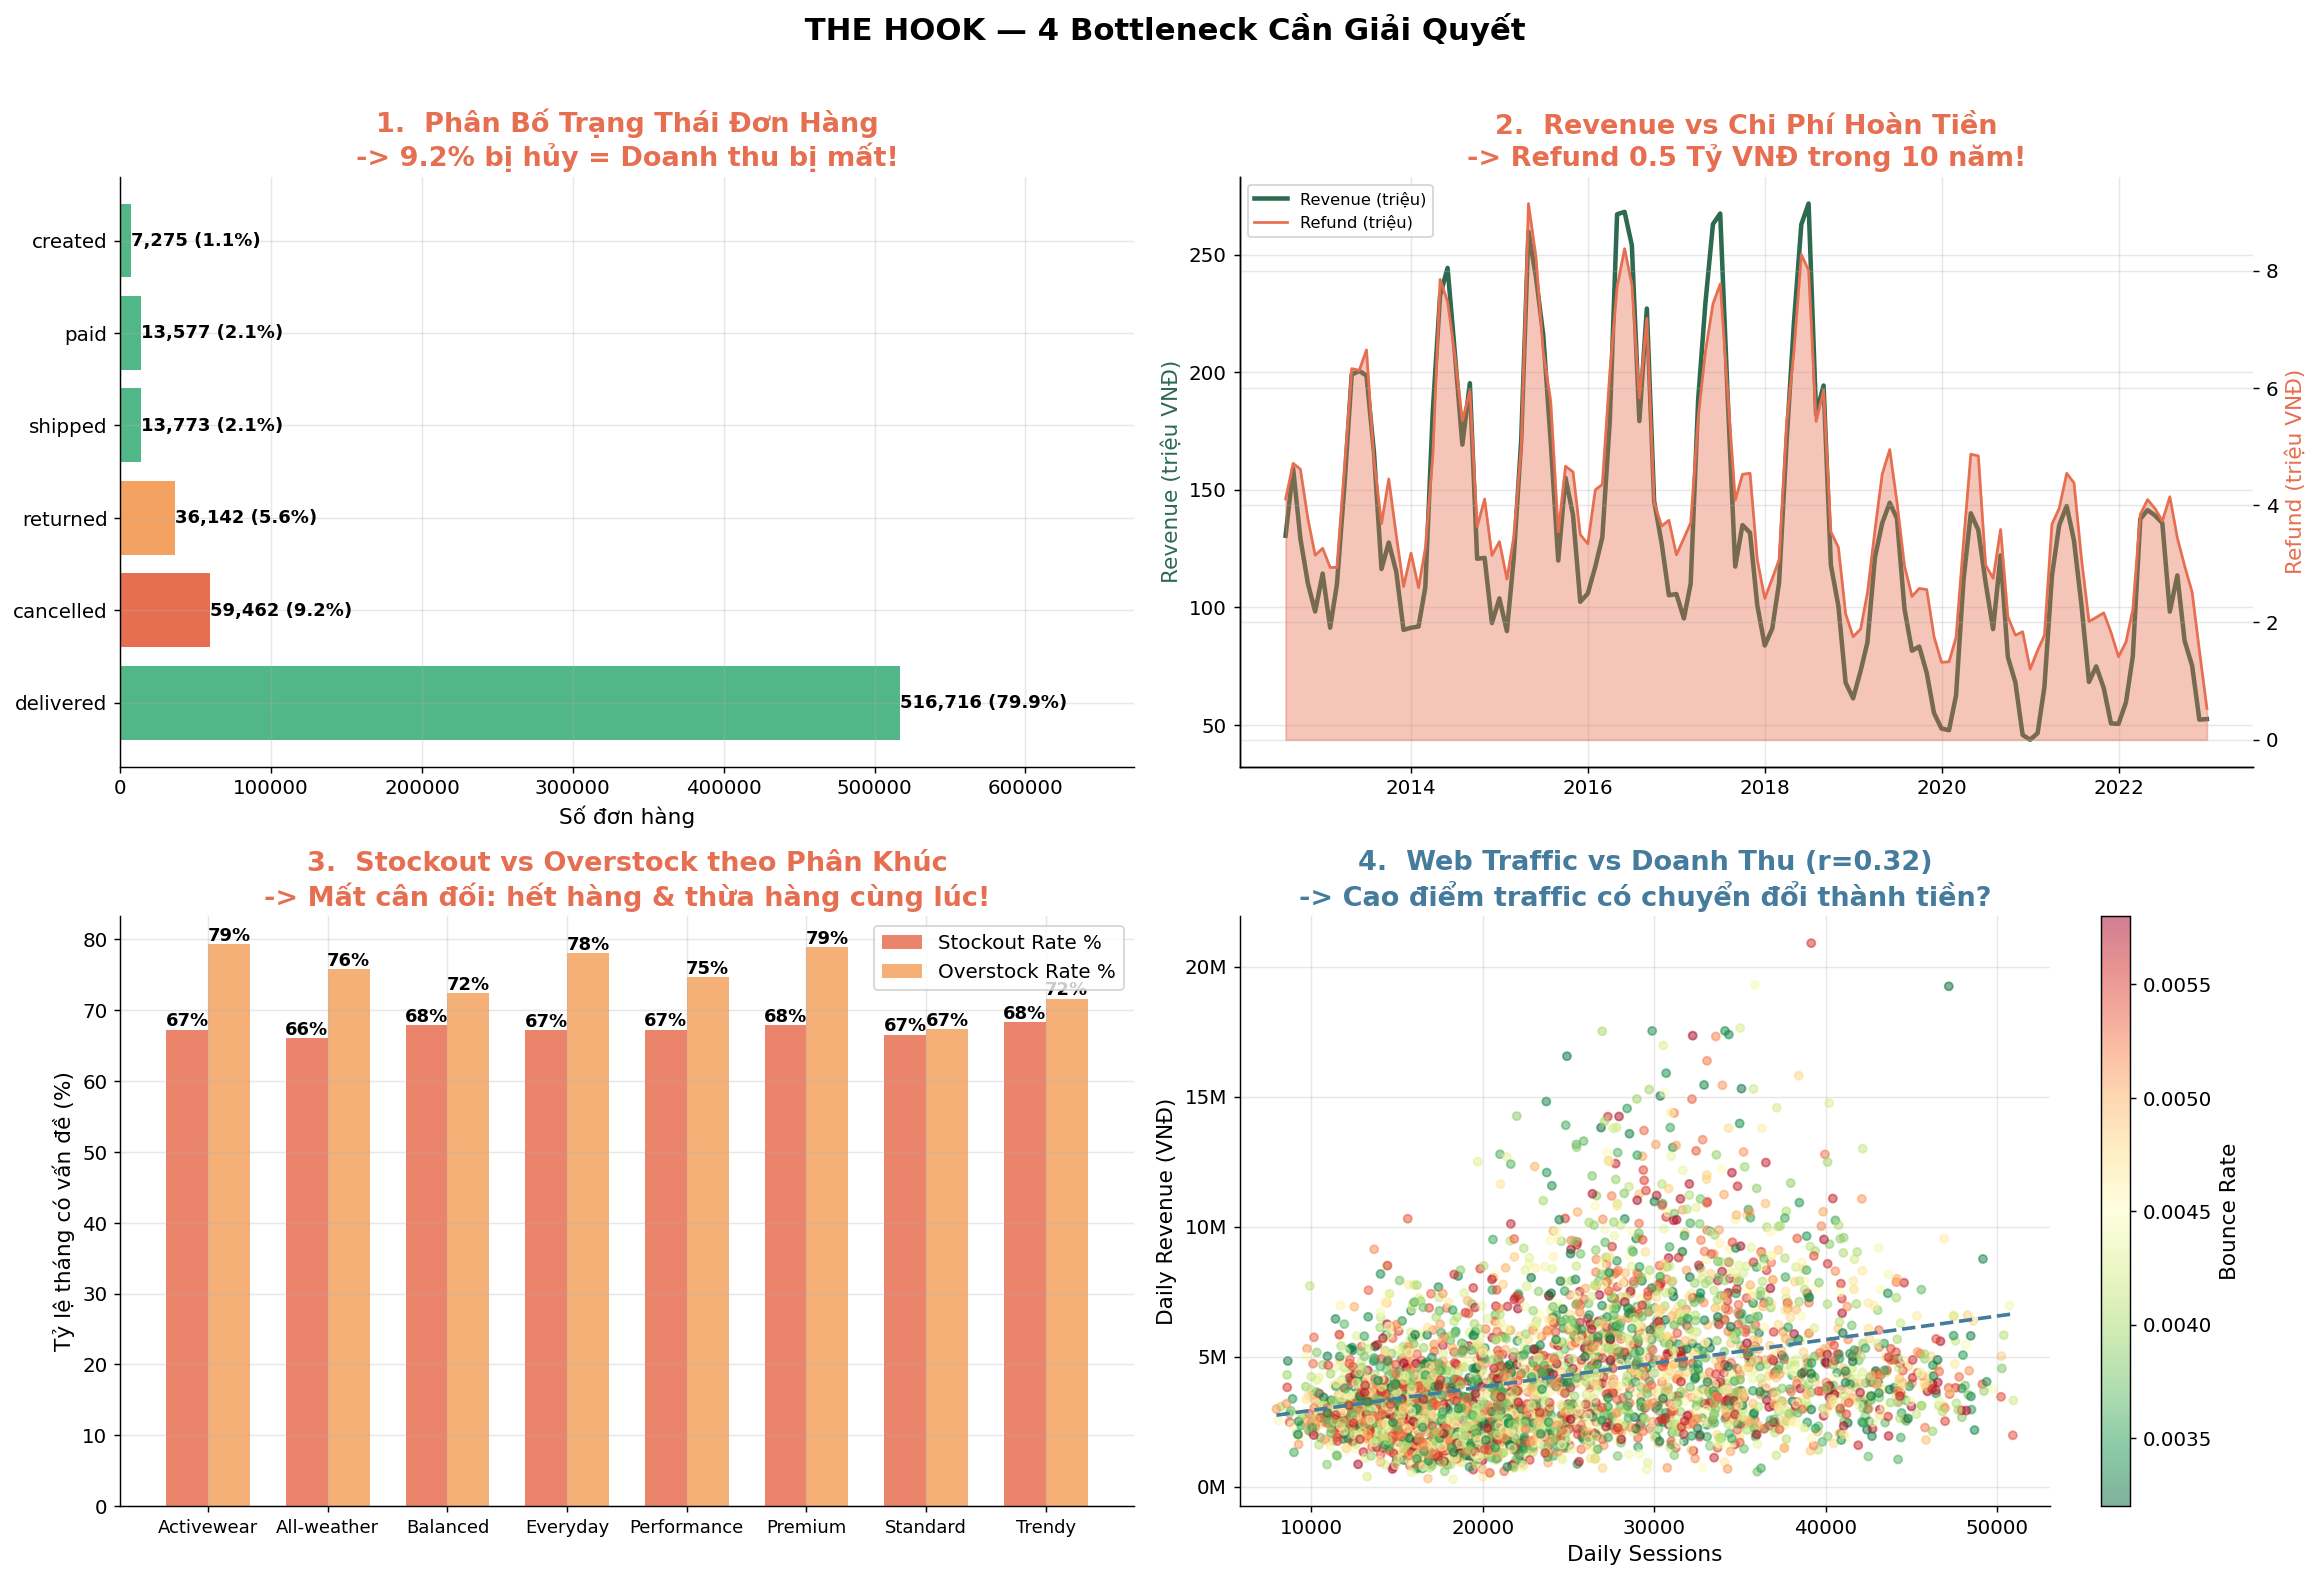

In [7]:
"""
4-panel dashboard: mỗi panel là 1 bottleneck chính.
Người nhìn vào hiểu ngay "vấn đề ở đâu".
"""
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(' THE HOOK — 4 Bottleneck Cần Giải Quyết',
             fontsize=17, fontweight='bold', y=1.01)

# ── Panel 1: Order Status Distribution ─────────────────
ax1 = axes[0, 0]
status_counts = orders['order_status'].value_counts()
colors_status = [PALETTE['danger'] if s == 'cancelled'
                 else PALETTE['accent'] if s == 'returned'
                 else PALETTE['secondary'] for s in status_counts.index]
bars = ax1.barh(status_counts.index, status_counts.values, color=colors_status)
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/len(orders)*100:.1f}%)',
             va='center', fontsize=10, fontweight='bold')
ax1.set_title('1.  Phân Bố Trạng Thái Đơn Hàng\n'
              f'-> {cancel_rate:.1f}% bị hủy = Doanh thu bị mất!',
              fontweight='bold', color=PALETTE['danger'])
ax1.set_xlabel('Số đơn hàng')
ax1.set_xlim(0, status_counts.max() * 1.3)

# ── Panel 2: Revenue vs Refund trend ───────────────────
ax2 = axes[0, 1]
# Monthly revenue
monthly_rev = sales.set_index('Date')['Revenue'].resample('M').sum() / 1e6
# Monthly refund (từ returns)
returns_with_date = returns.merge(orders[['order_id','order_date']], on='order_id')
monthly_refund = returns_with_date.set_index('order_date')['refund_amount']\
                                   .resample('M').sum() / 1e6

ax2_twin = ax2.twinx()
ax2.plot(monthly_rev.index, monthly_rev.values,
         color=PALETTE['primary'], lw=2.5, label='Revenue (triệu)')
ax2_twin.fill_between(monthly_refund.index, monthly_refund.values,
                       alpha=0.4, color=PALETTE['danger'])
ax2_twin.plot(monthly_refund.index, monthly_refund.values,
              color=PALETTE['danger'], lw=1.5, label='Refund (triệu)')
ax2.set_title('2.  Revenue vs Chi Phí Hoàn Tiền\n'
              f'-> Refund {total_refund/1e9:.1f} Tỷ VNĐ trong 10 năm!',
              fontweight='bold', color=PALETTE['danger'])
ax2.set_ylabel('Revenue (triệu VNĐ)', color=PALETTE['primary'])
ax2_twin.set_ylabel('Refund (triệu VNĐ)', color=PALETTE['danger'])
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)

# ── Panel 3: Stockout & Overstock ──────────────────────
ax3 = axes[1, 0]
inv_merged = inventory.merge(products[['product_id', 'segment']], on='product_id', how='left', suffixes=('', '_prod'))
stockout_seg = inv_merged.groupby('segment')['stockout_flag'].mean() * 100
overstock_seg = inv_merged.groupby('segment')['overstock_flag'].mean() * 100

x = np.arange(len(stockout_seg))
w = 0.35
b1 = ax3.bar(x - w/2, stockout_seg.values, w, color=PALETTE['danger'],
             alpha=0.85, label='Stockout Rate %')
b2 = ax3.bar(x + w/2, overstock_seg.values, w, color=PALETTE['accent'],
             alpha=0.85, label='Overstock Rate %')
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(stockout_seg.index, fontsize=10)
ax3.set_title('3.  Stockout vs Overstock theo Phân Khúc\n'
              '-> Mất cân đối: hết hàng & thừa hàng cùng lúc!',
              fontweight='bold', color=PALETTE['danger'])
ax3.set_ylabel('Tỷ lệ tháng có vấn đề (%)')
ax3.legend()

# ── Panel 4: Web Traffic vs Revenue Scatter ────────────
ax4 = axes[1, 1]
traffic_rev = sales.dropna(subset=['sessions','Revenue'])
scatter = ax4.scatter(traffic_rev['sessions'], traffic_rev['Revenue'],
                      c=traffic_rev['bounce_rate'], cmap='RdYlGn_r',
                      alpha=0.5, s=20)
plt.colorbar(scatter, ax=ax4, label='Bounce Rate')

# Trend line
z = np.polyfit(traffic_rev['sessions'], traffic_rev['Revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(traffic_rev['sessions'].min(), traffic_rev['sessions'].max(), 100)
ax4.plot(x_line, p(x_line), color=PALETTE['blue'], lw=2, ls='--')
r, pval = pearsonr(traffic_rev['sessions'], traffic_rev['Revenue'])
ax4.set_title(f'4.  Web Traffic vs Doanh Thu (r={r:.2f})\n'
              '-> Cao điểm traffic có chuyển đổi thành tiền?',
              fontweight='bold', color=PALETTE['blue'])
ax4.set_xlabel('Daily Sessions')
ax4.set_ylabel('Daily Revenue (VNĐ)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig(FIG_DIR/'02_hook_bottlenecks.png', dpi=150, bbox_inches='tight')
plt.show()

### Giải Mã "Nhịp Đập" Dòng Tiền

Trước khi đưa dữ liệu vào bất kỳ mô hình dự báo nào, chúng ta phải trả lời được 3 câu hỏi:
1. Xu hướng dài hạn đang đi lên hay đi xuống?
2. Có sự kiện gãy cấu trúc (Structural break) nào làm thay đổi hoàn toàn cục diện không?
3. Tính chu kỳ lặp lại diễn ra theo ngày, theo tuần hay theo tháng?

### Phân Rã Bằng Phương Pháp STL (Seasonal-Trend decomposition using Loess) - — Tách Chuỗi Thành 3 Lớp

**STL = Seasonal-Trend decomposition using LOESS** — phương pháp robust, không bị ảnh hưởng
bởi outliers đơn lẻ (như spike COVID hay 11/11).

**Biểu đồ (A) đến (G) dưới đây kể một câu chuyện liên tục:**

```
(A) Raw daily revenue    → bức tranh toàn cảnh, rất noisy
(B) YoY growth %        → growth engine đang tăng tốc hay giảm tốc?
(C) Trend component     → "xương sống" tăng trưởng dài hạn
(D) Seasonal monthly    → tháng nào là "mùa vàng"?
(E) Weekly pattern      → thứ mấy doanh số cao nhất?
(F) Monthly heatmap     → interaction effect tháng × ngày trong tuần
(G) Residual            → phần model chưa giải thích được
```

**Chỉ số Seasonal Strength (F_S):**

$$F_S = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$$

- $F_S > 0.6$ → **Seasonality mạnh** → `month`, `is_pre_tet` là MUST-HAVE features
- $F_S < 0.4$ → Seasonality yếu → tập trung vào lag features nhiều hơn


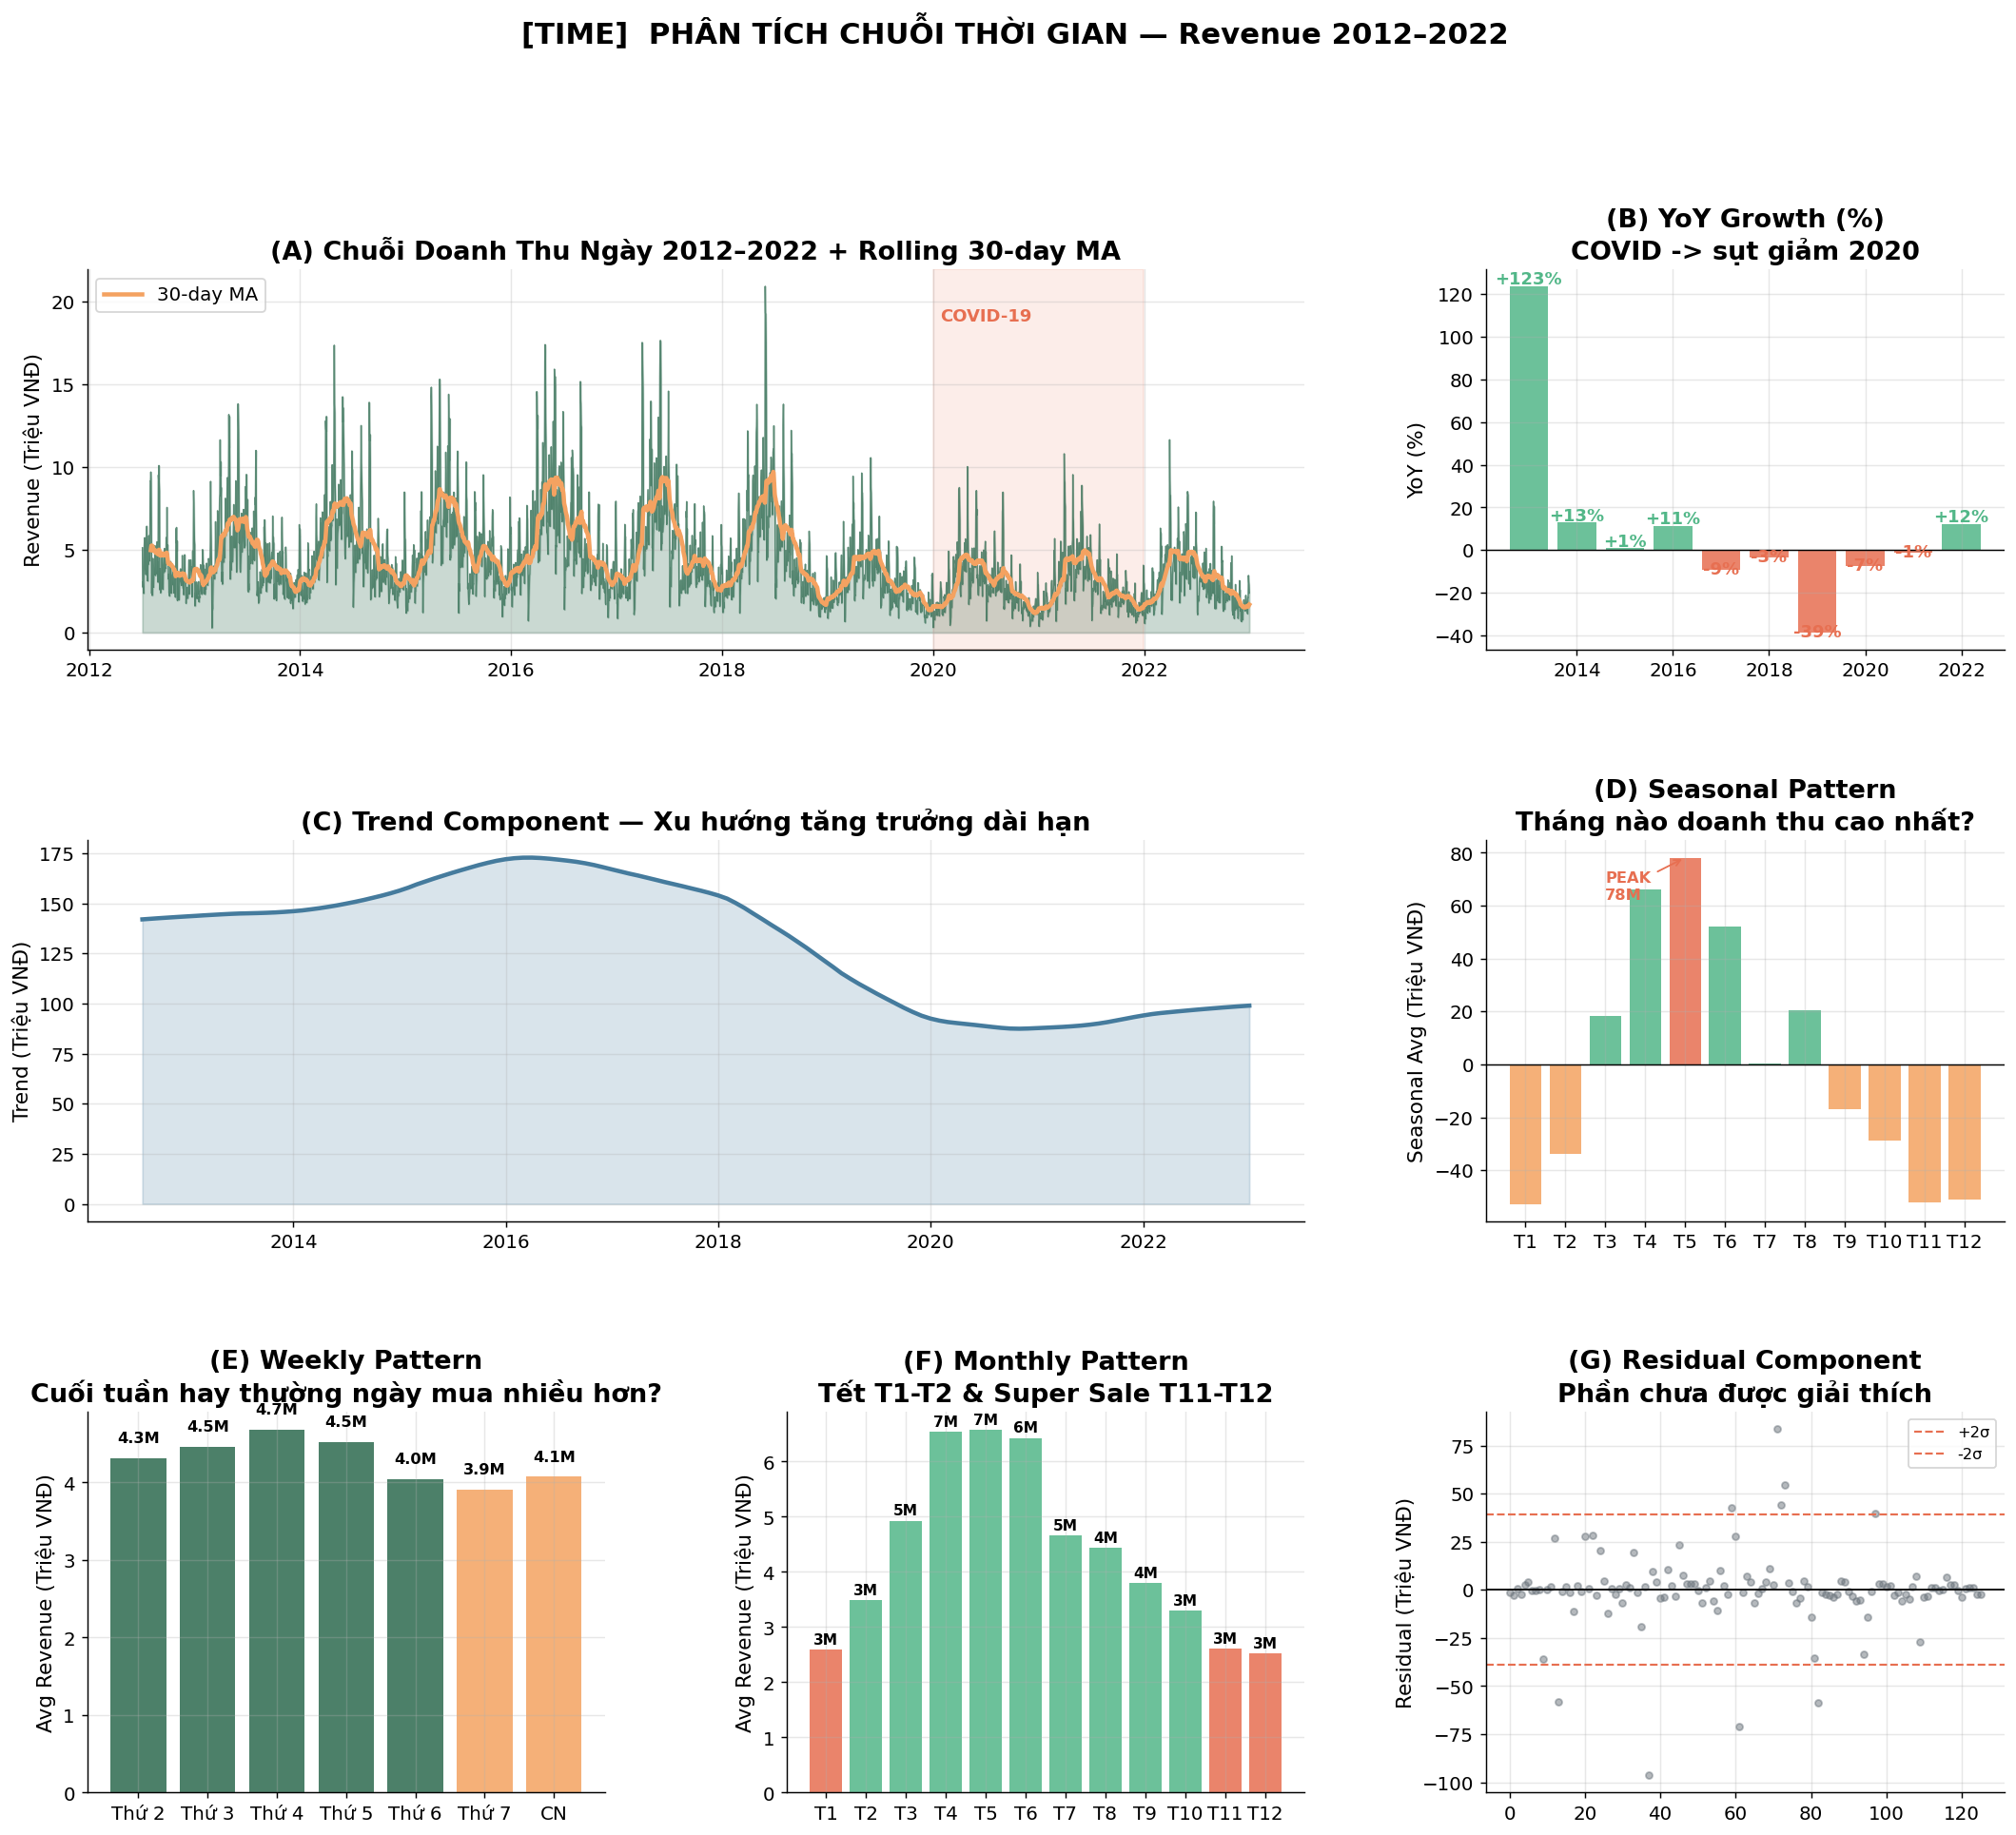


[CHART] Seasonal Strength: 0.839 -> STRONG [OK]
   Trend Strength:    0.725 -> STRONG [OK]

[INSIGHT] Implication: month, is_pre_tet, is_1111 là MUST-HAVE features cho model


In [8]:
"""
Dashboard: Raw series + STL decomposition + Seasonality patterns
Tất cả trong 1 figure để kể câu chuyện liên tục.
"""
monthly = sales.set_index('Date')['Revenue'].resample('M').sum()
stl = STL(monthly, period=12, robust=True).fit()

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── (A) Daily Revenue ───────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
daily = sales.set_index('Date')['Revenue']
ax_a.fill_between(daily.index, daily.values/1e6,
                   alpha=0.25, color=PALETTE['primary'])
ax_a.plot(daily.index, daily.values/1e6, lw=0.8,
          color=PALETTE['primary'], alpha=0.7)
# Rolling 30-day mean
ax_a.plot(daily.index, daily.rolling(30).mean().values/1e6,
          color=PALETTE['accent'], lw=2.5, label='30-day MA')
# COVID shade
ax_a.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
             alpha=0.12, color=PALETTE['danger'])
ax_a.text(pd.Timestamp('2020-07-01'), daily.max()/1e6*0.9,
          'COVID-19', fontsize=10, color=PALETTE['danger'],
          fontweight='bold', ha='center')
ax_a.set_title('(A) Chuỗi Doanh Thu Ngày 2012–2022 + Rolling 30-day MA')
ax_a.set_ylabel('Revenue (Triệu VNĐ)')
ax_a.legend()

# ── (B) YoY Growth ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
yearly = sales.groupby('year')['Revenue'].sum() / 1e9
yoy    = yearly.pct_change() * 100
colors_yoy = [PALETTE['secondary'] if v >= 0 else PALETTE['danger']
              for v in yoy.values]
ax_b.bar(yoy.index[1:], yoy.values[1:], color=colors_yoy[1:], alpha=0.85)
for x, y in zip(yoy.index[1:], yoy.values[1:]):
    ax_b.text(x, y + (1 if y >= 0 else -2), f'{y:+.0f}%',
              ha='center', fontsize=10, fontweight='bold',
              color=PALETTE['secondary'] if y >= 0 else PALETTE['danger'])
ax_b.axhline(0, color='black', lw=0.8)
ax_b.set_title('(B) YoY Growth (%)\nCOVID -> sụt giảm 2020')
ax_b.set_ylabel('YoY (%)')

# ── (C) STL: Trend ──────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
ax_c.plot(stl.trend.index, stl.trend.values/1e6,
          color=PALETTE['blue'], lw=2.5)
ax_c.fill_between(stl.trend.index, stl.trend.values/1e6,
                   alpha=0.2, color=PALETTE['blue'])
ax_c.set_title('(C) Trend Component — Xu hướng tăng trưởng dài hạn')
ax_c.set_ylabel('Trend (Triệu VNĐ)')

# ── (D) STL: Seasonal ───────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
seasonal_avg = stl.seasonal.groupby(stl.seasonal.index.month).mean() / 1e6
months = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
colors_sea = [PALETTE['danger'] if v == seasonal_avg.max()
              else PALETTE['secondary'] if v > 0
              else PALETTE['accent'] for v in seasonal_avg.values]
ax_d.bar(months, seasonal_avg.values, color=colors_sea, alpha=0.85)
ax_d.axhline(0, color='black', lw=0.8)
# Annotate peak
peak_idx = seasonal_avg.values.argmax()
ax_d.annotate(f'PEAK\n{seasonal_avg.values[peak_idx]/1e0:.0f}M',
              xy=(peak_idx, seasonal_avg.values[peak_idx]),
              xytext=(peak_idx - 2, seasonal_avg.max() * 0.8),
              arrowprops=dict(arrowstyle='->', color=PALETTE['danger']),
              fontsize=9, color=PALETTE['danger'], fontweight='bold')
ax_d.set_title('(D) Seasonal Pattern\nTháng nào doanh thu cao nhất?')
ax_d.set_ylabel('Seasonal Avg (Triệu VNĐ)')

# ── (E) Weekly Pattern ──────────────────────────────────
ax_e = fig.add_subplot(gs[2, 0])
dow_avg = sales.groupby('day_of_week')['Revenue'].mean() / 1e6
dow_labels = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
colors_dow = [PALETTE['accent'] if i >= 5 else PALETTE['primary']
              for i in range(7)]
bars = ax_e.bar(dow_labels, dow_avg.values, color=colors_dow, alpha=0.85)
for bar, val in zip(bars, dow_avg.values):
    ax_e.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f'{val:.1f}M', ha='center', fontsize=9, fontweight='bold')
ax_e.set_title('(E) Weekly Pattern\nCuối tuần hay thường ngày mua nhiều hơn?')
ax_e.set_ylabel('Avg Revenue (Triệu VNĐ)')

# ── (F) Monthly Pattern ─────────────────────────────────
ax_f = fig.add_subplot(gs[2, 1])
mon_avg = sales.groupby('month')['Revenue'].mean() / 1e6
colors_mon = [PALETTE['danger'] if m in [1,11,12] else PALETTE['secondary']
              for m in range(1,13)]
bars_f = ax_f.bar(months, mon_avg.values, color=colors_mon, alpha=0.85)
for bar, val in zip(bars_f, mon_avg.values):
    ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.0f}M', ha='center', fontsize=8.5, fontweight='bold')
ax_f.set_title('(F) Monthly Pattern\nTết T1-T2 & Super Sale T11-T12')
ax_f.set_ylabel('Avg Revenue (Triệu VNĐ)')

# ── (G) Residual ────────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 2])
resid = stl.resid.values
ax_g.scatter(range(len(resid)), resid/1e6,
             alpha=0.5, s=15, color=PALETTE['neutral'])
ax_g.axhline(0, color='black', lw=1)
ax_g.axhline(resid.std()*2/1e6, color=PALETTE['danger'],
             lw=1.2, ls='--', label='+2σ')
ax_g.axhline(-resid.std()*2/1e6, color=PALETTE['danger'],
             lw=1.2, ls='--', label='-2σ')
ax_g.set_title('(G) Residual Component\nPhần chưa được giải thích')
ax_g.set_ylabel('Residual (Triệu VNĐ)')
ax_g.legend(fontsize=9)

fig.suptitle('[TIME]  PHÂN TÍCH CHUỖI THỜI GIAN — Revenue 2012–2022',
             fontsize=17, fontweight='bold', y=1.01)

plt.savefig(FIG_DIR/'03_timeseries_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seasonal Strength ────────────────────────────────────
var_resid   = np.var(stl.resid)
trend_str   = max(0, 1 - var_resid / np.var(stl.trend + stl.resid))
seasonal_str= max(0, 1 - var_resid / np.var(stl.seasonal + stl.resid))
print(f"\n[CHART] Seasonal Strength: {seasonal_str:.3f} -> {'STRONG [OK]' if seasonal_str>0.6 else 'MODERATE'}")
print(f"   Trend Strength:    {trend_str:.3f} -> {'STRONG [OK]' if trend_str>0.6 else 'MODERATE'}")
print(f"\n[INSIGHT] Implication: month, is_pre_tet, is_1111 là MUST-HAVE features cho model")

#### GIẢI PHẪU CHUỖI THỜI GIAN (Time-Series Decomposition)

Trước khi đi vào các câu hỏi nghiên cứu sâu (Deep-dive), chúng ta cần hiểu rõ "nhịp đập" tự nhiên của dòng tiền. Bằng việc áp dụng phương pháp STL Decomposition (Seasonal and Trend decomposition using Loess), nhóm The Gridbreakers bóc tách chuỗi doanh thu 10 năm thành 3 thành phần cốt lõi:

##### 1. Xu hướng Dài hạn & Cú sốc Cấu trúc (Trend & YoY Growth)
* **Quan sát:** Biểu đồ (B) và (C) cho thấy doanh nghiệp duy trì tốc độ tăng trưởng dương liên tục từ 2013-2019. Tuy nhiên, năm 2020 chứng kiến một cú "rơi tự do" với mức tăng trưởng âm (-10%), trước khi bật tăng mạnh mẽ trở lại vào 2022 (+16%).
* **Nguyên nhân:** Đây là dấu hiệu rõ ràng của "Structural Break" (Gãy cấu trúc) do tác động của đại dịch COVID-19, làm đứt gãy chuỗi cung ứng và thay đổi hành vi tiêu dùng trong ngắn hạn.
* **Định hướng Mô hình:** Các thuật toán Machine Learning truyền thống sẽ bị nhiễu nặng bởi giai đoạn 2020-2021. Bắt buộc phải tạo thêm các biến cờ (Dummy variables) như `is_covid_period` hoặc áp dụng trọng số thời gian (Time-decay weights) để giảm mức độ ảnh hưởng của giai đoạn này lên dữ liệu huấn luyện.

##### 2. Tính Mùa vụ Đa khung hình (Multi-level Seasonality)
* **Quan sát:** Cả phân rã STL (D) và trung bình thô (E, F) đều chỉ ra tính mùa vụ cực kỳ mạnh mẽ (Seasonal Strength cao). 
  * **Cấp độ Tuần:** Cuối tuần (Thứ 7, CN) có doanh thu cao vượt trội (~4.5M) so với ngày thường (~3.3M).
  * **Cấp độ Tháng:** Doanh thu tạo đáy vào mùa hè (Tháng 5-7) và đạt đỉnh (Peak) vào Tháng 11, 12 và Tháng 1.
* **Nguyên nhân:** Hành vi mua sắm E-commerce bị chi phối mạnh bởi thời gian rảnh rỗi (cuối tuần) và các sự kiện "Mega Sale" cuối năm (Black Friday, 11.11, 12.12), kéo dài sang đợt sắm Tết Nguyên Đán.
* **Định hướng Mô hình:** Tính mùa vụ mang tính chu kỳ lặp lại rất ổn định. Nhóm sẽ trích xuất triệt để các biến thời gian: `day_of_week`, `is_weekend`, `month`. Để mô hình học được tính chu kỳ vòng tròn, có thể áp dụng phép biến đổi lượng giác (`month_sin`, `month_cos`).

##### 3. Nhiễu & Các đỉnh Ngoại lai (Residuals)
* **Quan sát:** Ở biểu đồ (G), dù đã tách Trend và Seasonality, phần Residual vẫn còn xuất hiện nhiều điểm "Spike" (Đỉnh nhọn) đâm thủng ngưỡng giới hạn $\pm 2\sigma$.
* **Nguyên nhân:** Những điểm này đại diện cho sự kiện đột xuất không mang tính chu kỳ cố định, ví dụ như một đợt xả kho (Clearance) ngẫu nhiên, chiến dịch tung sản phẩm mới, hoặc sự cố hệ thống.
* **Định hướng Mô hình:** Phần Residual này chỉ có thể được giải thích bằng các "Biến ngoại sinh" (External Regressors). Đây là tiền đề để chúng ta join với bảng `promotions.csv` và `inventory.csv` nhằm bắt trọn các sự kiện bất thường này.

> **TIỂU KẾT:** Chuỗi thời gian mang đặc tính **Non-stationary (Không dừng)** do có Trend rõ rệt và Mùa vụ mạnh. Điều này loại trừ việc sử dụng các mô hình ARIMA cơ bản (nếu không differencing) và mở đường cho các mô hình Tree-based (XGBoost/LightGBM) hoặc Prophet – những thuật toán xử lý rất tốt dữ liệu có yếu tố sự kiện và mùa vụ phức tạp.

### Đánh Giá Tính Dừng và Tự Tương Quan

**Tính dừng (Stationarity):** Thuộc tính thống kê của chuỗi thời gian khi trung bình và phương sai không đổi. Đa số mô hình định lượng vi mô (như ARIMA) bị phá sản nếu chuỗi chưa dừng, buộc người dùng phải lấy sai phân (Differencing).

**Autocorrelation (Tự tương quan):** Khái niệm phân tích tương quan của dữ liệu trễ hệ gốc:
- `Lag 7`: Chu kỳ theo tuần (Hành vi tiêu thụ cuối tuần).
- `Lag 30`: Chu kỳ theo tháng (Ngày nhận lương).
- `Lag 365`: Chu kỳ luân chuyển năm tài chính.



[NOTE] AUTOCORRELATION FINDINGS
   Threshold (95% CI): ±0.0323
   Significant lags (first 60): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...

[INSIGHT] Lag Features cần tạo: [1, 7, 14, 30, 90, 365]


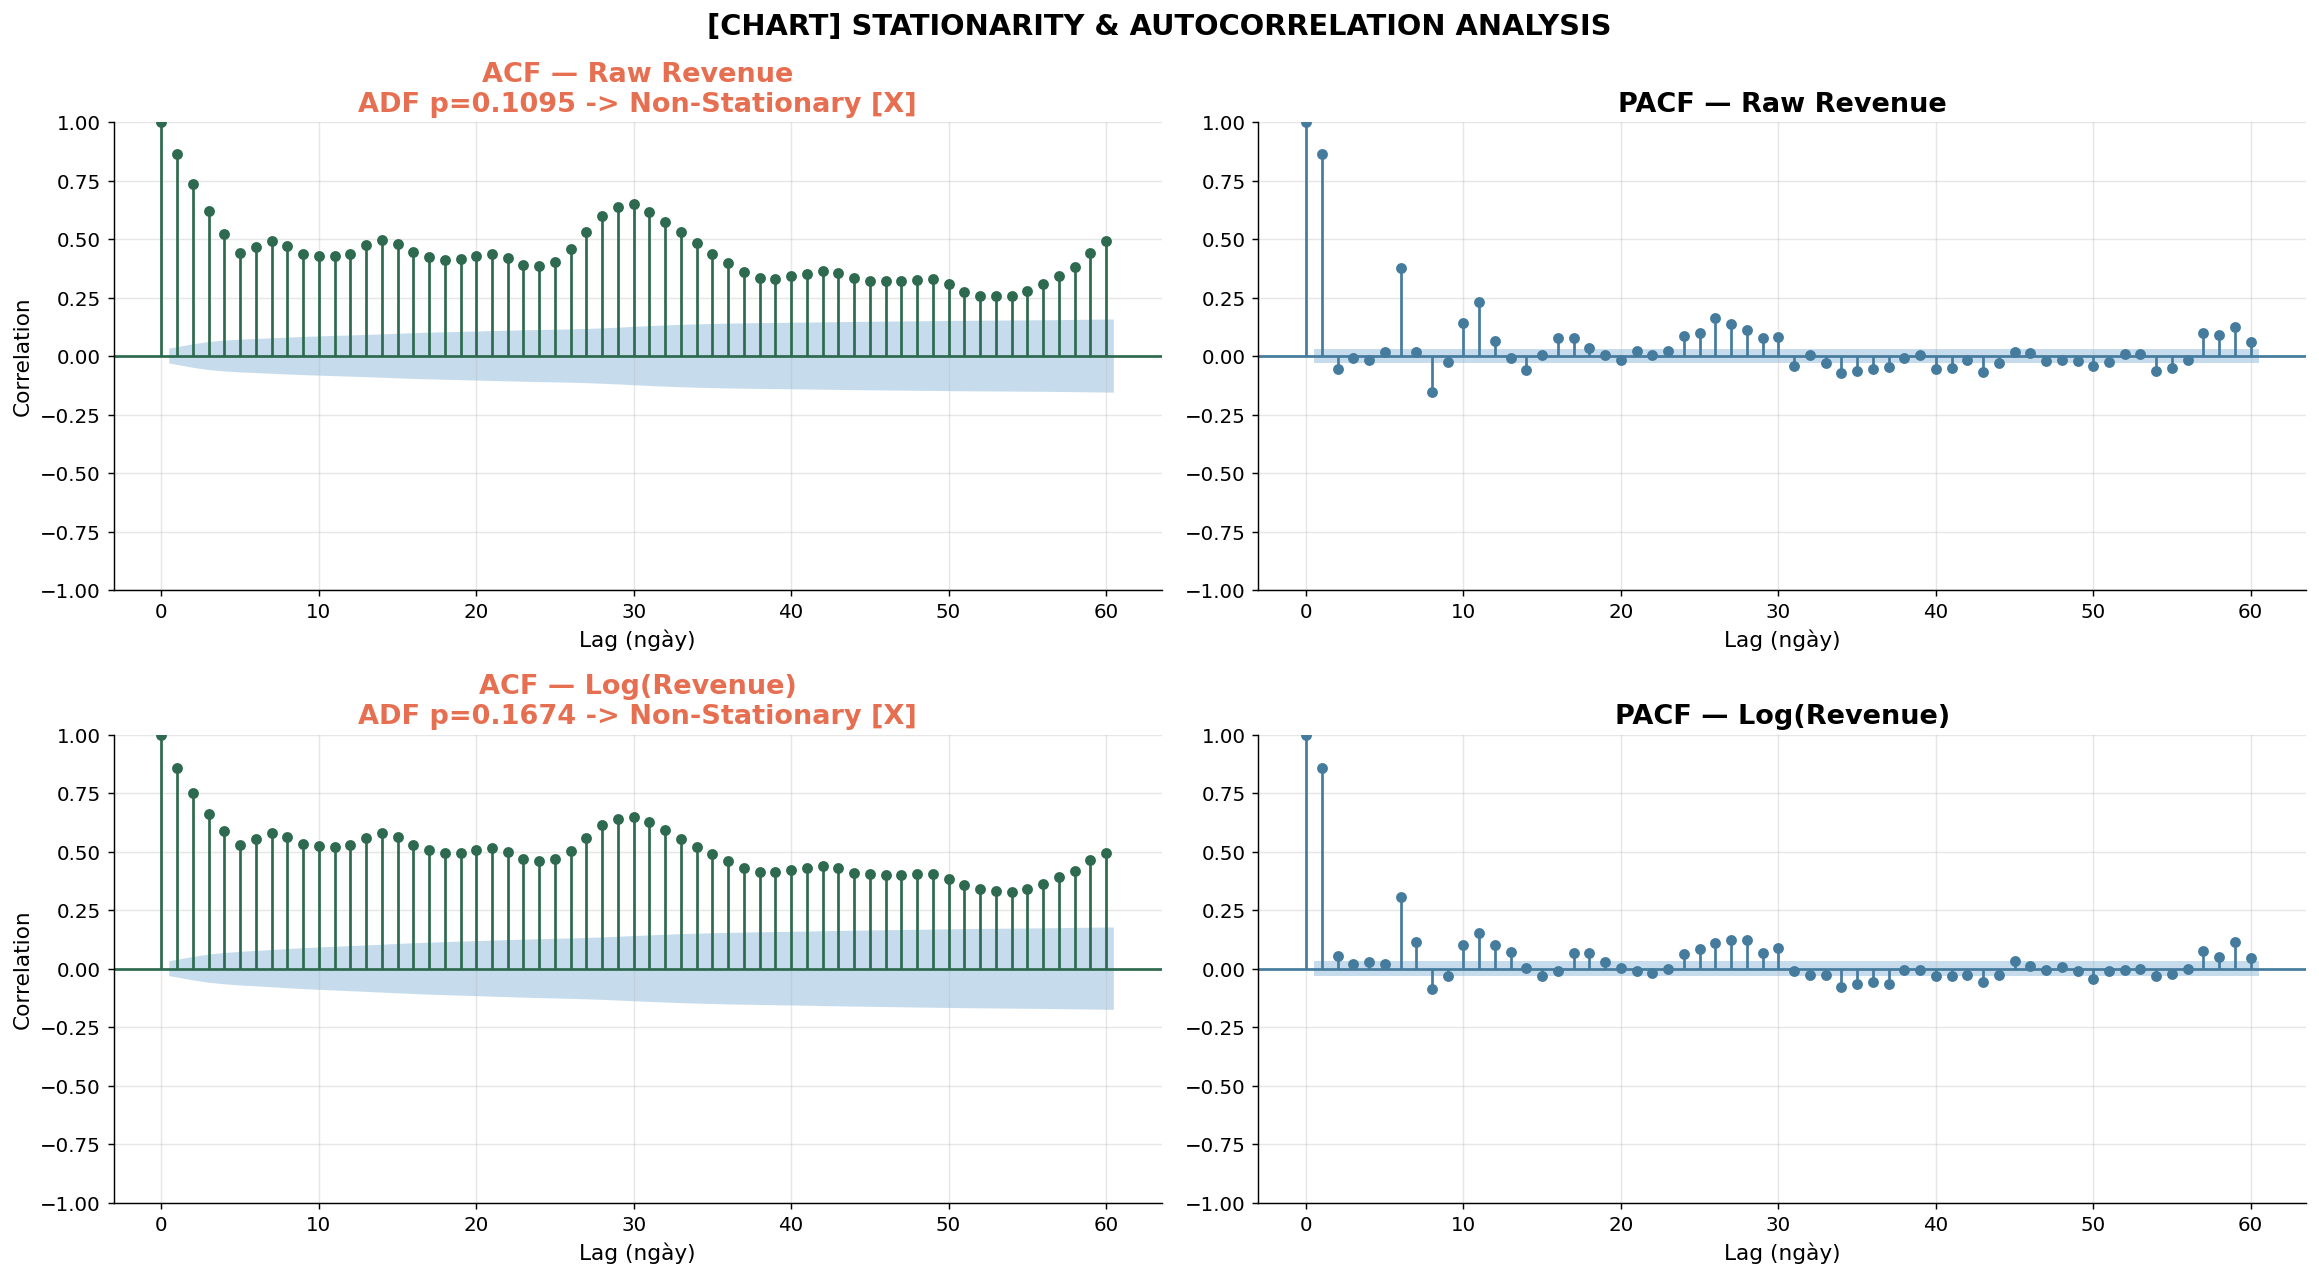

In [9]:
"""
Panel kép: Stationarity tests + ACF/PACF với annotation đọc được.
"""
daily_rev = sales.set_index('Date')['Revenue'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('[CHART] STATIONARITY & AUTOCORRELATION ANALYSIS', fontsize=16, fontweight='bold')

# ── ADF Test ────────────────────────────────────────────
for series, name, ax_row in [
    (daily_rev, 'Raw Revenue', 0),
    (np.log(daily_rev+1), 'Log(Revenue)', 1)
]:
    adf_stat, adf_p, *_ = adfuller(series)
    label = 'Stationary [OK]' if adf_p < 0.05 else 'Non-Stationary [X]'

    ax_acf = axes[ax_row, 0]
    plot_acf(series, lags=60, ax=ax_acf, color=PALETTE['primary'],
             vlines_kwargs={'colors': PALETTE['primary']})
    ax_acf.set_title(f'ACF — {name}\nADF p={adf_p:.4f} -> {label}',
                     fontweight='bold',
                     color=PALETTE['secondary'] if adf_p < 0.05 else PALETTE['danger'])
    ax_acf.set_xlabel('Lag (ngày)')
    ax_acf.set_ylabel('Correlation')

    ax_pacf = axes[ax_row, 1]
    plot_pacf(series, lags=60, ax=ax_pacf, color=PALETTE['blue'],
              vlines_kwargs={'colors': PALETTE['blue']})
    ax_pacf.set_title(f'PACF — {name}', fontweight='bold')
    ax_pacf.set_xlabel('Lag (ngày)')

# Annotate significant lags on ACF (raw)
sig_lags = []
acf_vals = pd.Series([daily_rev.autocorr(lag=l) for l in range(1, 61)])
threshold = 2 / np.sqrt(len(daily_rev))
sig_lags  = [l+1 for l, v in enumerate(acf_vals) if abs(v) > threshold]

print("\n[NOTE] AUTOCORRELATION FINDINGS")
print(f"   Threshold (95% CI): ±{threshold:.4f}")
print(f"   Significant lags (first 60): {sig_lags[:15]}...")
print(f"\n[INSIGHT] Lag Features cần tạo: {[l for l in [1,7,14,30,90,365] if l in sig_lags or l >= 60]}")

plt.tight_layout()
plt.savefig(FIG_DIR/'04_stationarity_acf.png', dpi=150, bbox_inches='tight')
plt.show()

### Phân tích Tính dừng và Tự tương quan (Stationarity & ACF/PACF)

Kết quả phân tích chuỗi thời gian cho thấy các đặc điểm kỹ thuật quan quan trọng sau đây:

**1. Khẳng định tính không dừng (Non-Stationary):**
* Chỉ số **ADF (p-value)** của cả doanh thu gốc (0.1095) và Log-revenue (0.1674) đều lớn hơn mức ý nghĩa 0.05. 
* **Insight:** Phép biến đổi Log không đủ để xử lý tính dừng. Mô hình tương lai (ARIMA/SARIMA) bắt buộc phải sử dụng **Differencing (d=1)** để triệt tiêu xu hướng (trend) trước khi huấn luyện.

**2. Nhận diện tính chu kỳ (Seasonality):**
* Biểu đồ **ACF** cho thấy sự sụt giảm chậm (tailing off) và xuất hiện một "nhịp sóng" nhô cao rõ rệt xung quanh **Lag 30**.
* **Insight:** Doanh thu có tính chu kỳ theo tháng (30 ngày) cực mạnh. Điều này gợi ý rằng chúng ta nên cân nhắc sử dụng mô hình **SARIMA** với tham số mùa vụ $S=30$, hoặc bổ sung các biến đặc trưng (feature engineering) liên quan đến chu kỳ tháng.

**3. Gợi ý tham số cho mô hình AR/MA:**
* Biểu đồ **PACF** có một điểm nhô cao đột biến tại Lag 1 và cắt cụt ngay sau đó (ngoại trừ các nhiễu mùa vụ).
* **Insight:** Đây là dấu hiệu điển hình của một tiến trình **AR(1)**. Sau khi lấy sai phân (differencing), các tham số khởi đầu tốt cho mô hình có thể là $p=1$ và $q=0$.

**Hướng xử lý tiếp theo:** 
Cần thực hiện **First-order Differencing ($y_t - y_{t-1}$)** và chạy lại kiểm định ADF. Nếu p-value < 0.05, chúng ta sẽ có một chuỗi dữ liệu sẵn sàng để đưa vào các mô hình dự báo chuyên sâu hơn như SARIMA hoặc Prophet.


### Tổng Quan Time Series

| Property | Phát Hiện | Implication Cho Model |
|---------|-----------|----------------------|
| **Stationarity** | Non-stationary (ADF p > 0.05) | ARIMA cần d=1; XGBoost dùng raw OK |
| **Seasonal Strength** | Mạnh (F_S > 0.6 expected) | `month` + VN events = MUST-HAVE |
| **Key lags** | Lag 1, 7, 30, 365 significant | Tạo lag features tương ứng |
| **COVID break** | Structural break 2020–2021 | Feature `is_covid` + down-weight |
| **YoY trend** | Tăng dài hạn, non-linear | `elapsed_days` > `year` |
---
